<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 1.3</h1>

### Buffon's Needle Experiment

The **Buffon's needle experiment** is a classical geometrical probability problem that provides a method for estimating the value of $\pi$. Consider a set of parallel lines separated by a distance $a$ and a needle of length $l$, with $l\leq a$. If the needle is thrown randomly onto the plane, the probability that it intersects one of the lines is

$$
P_{\mathrm{hit}} = \frac{2l}{\pi a}.
$$

Consequently, an estimate of $\pi$ can be obtained from the measured probability of intersection:

$$
\pi = \frac{2l}{aP_{\mathrm{hit}}}.
$$

To simulate the random throwing of the needle, two independent quantities have to be sampled: the distance $r$ between the centre of the needle and the closest line, and its orientation with respect to the lines.

The distance $r$ is uniformly distributed between zero and half the distance between two consecutive lines,

$$
r\sim U\left(0,\frac{a}{2}\right),
$$

The orientation of the needle is isotropic. Instead of generating the angle directly, it is obtained by uniformly sampling a point $(x,y)$ inside the unit circle. This is done by first generating

$$
x,y\sim U(-1,1)
$$

and accepting the point only if

$$
x^2+y^2\leq1.
$$

The distance of the point from the origin is then

$$
\rho=\sqrt{x^2+y^2},
$$

and the relevant angular factor can be obtained as

$$
|\sin\theta|=\frac{|y|}{\rho}.
$$

The needle intersects a line when the projection of half of its length onto the direction perpendicular to the lines is greater than or equal to the distance $r$ of its centre from the closest line. Therefore, the condition for an intersection is

$$
r\leq\frac{l}{2}|\sin\theta|.
$$

For each throw, the above condition is checked and a value of $1$ is assigned if the needle intersects a line, and $0$ otherwise. The probability of intersection is then estimated from the fraction of successful throws,

$$
P_{\mathrm{hit}} \simeq
\frac{N_{\mathrm{hit}}}{M},
$$

where $N_{\mathrm{hit}}$ is the number of intersections observed in $M$ throws. This estimate is then used to calculate $\pi$ through

$$
\pi \simeq \frac{2l}{aP_{\mathrm{hit}}}.
$$

In the simulation, a total of $M=10^5$ throws is performed divided into $N=100$ blocks, each containing $M/N=10^3$ throws. Furthermore a ratio of $l/a = 0.8$ between the length of the stick and the line spacing was selected. 

The **blocking method** is then applied to the estimates of $\pi$ obtained from the individual blocks. The progressive averages over the blocks are used to study the convergence of the estimate and to evaluate its statistical uncertainty.

### Error propagation

The uncertainty on $\pi$ is obtained by propagating the statistical uncertainty of the measured intersection probability $P_{\mathrm{hit}}$ through

$$
\pi(P_{\mathrm{hit}})=
\frac{2l}{aP_{\mathrm{hit}}}.
$$

Assuming that $l$ and $a$ are fixed quantities, the uncertainty is

$$
\sigma_\pi=
\left|
\frac{\partial\pi}{\partial P_{\mathrm{hit}}}
\right|
\sigma_{P_{\mathrm{hit}}}.
$$

Since

$$
\frac{\partial\pi}{\partial P_{\mathrm{hit}}}=
-\frac{2l}{aP_{\mathrm{hit}}^2},
$$

the propagated uncertainty is therefore

$$
\boxed{
\sigma_\pi=
\frac{2l}{aP_{\mathrm{hit}}^2}
\sigma_{P_{\mathrm{hit}}}
}.
$$

This gives the statistical uncertainty associated with the estimate of $\pi$ obtained from the simulation.


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math

In [2]:
ave_prog = np.loadtxt('ave_prog.txt')
err_prog = np.loadtxt('err_prog.txt')

In [3]:
M = 100000
N = 100
L = int(M/N)
x = np.arange(N)
x*=L
pi = 3.14159265

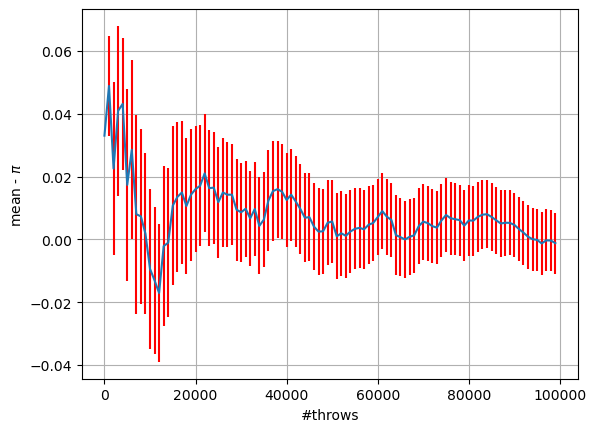

In [4]:
plt.errorbar(x, ave_prog - pi , yerr=err_prog, ecolor='red')
plt.xlabel('#throws')
plt.ylabel('mean - $\pi$')
plt.grid(True)
plt.show()

Figure 1. The plot shows the results of the Buffon needle experiment, performed with $M=10^5$ throws and divided into $N=100$ blocks, corresponding to $10^3$ throws per block. The ratio between the needle length and the spacing between the lines is fixed to $l/a=0.8$. The graph reports the progressive average of the estimate of $\pi$, together with its associated statistical uncertainty.

The progressive average shows a clear convergence towards the expected value of $\pi$. After an initial fluctuation, the estimate progressively stabilizes around the theoretical value, while the associated uncertainty decreases as the number of throws increases. This result confirms the effectiveness of the Monte Carlo method in estimating $\pi$ through a purely probabilistic experiment.
